In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from typing import Tuple, Dict, List, Optional
from torch.utils.data import Dataset, DataLoader, random_split

from Data_loader_PKL import create_dataloaders, load_full_dataset

In [5]:
# Example: Load data with train/val/test splits
CACHE_DIR = "./Chr20_all_cached"
ENFORMER_TSV = "./Chr20_all_cached/enfemb_chr20_res1000_dim512.tsv.gz"

print("=" * 70)
print("MULTIMODAL DATA LOADER - Example Usage")
print("=" * 70)

# Option 1: Separate dataloaders
print("\n📦 Creating train/val/test dataloaders...")
train_loader, val_loader, test_loader = create_dataloaders(
    cache_dir=CACHE_DIR,
    enformer_tsv=ENFORMER_TSV,
    batch_size=8,
    train_split=0.7,
    val_split=0.15,
    test_split=0.15,
    num_workers=0
)

# Inspect one batch  (note: return order = hic, enf, atac, rna)
print("\n🔍 Sample batch from train set:")
hic, enf, atac, rna = next(iter(train_loader))
print(f"   HiC:      {hic.shape}  | dtype: {hic.dtype}")
print(f"   Enformer: {enf.shape}  | dtype: {enf.dtype}")
print(f"   ATAC:     {atac.shape} | dtype: {atac.dtype}")
print(f"   RNA:      {rna.shape}  | dtype: {rna.dtype}")
print(rna)
print(f"   Values - HiC: [{hic.min():.3f}, {hic.max():.3f}] | "
        f"ATAC: [{atac.min():.3f}, {atac.max():.3f}] | "
        f"RNA: [{rna.min():.3f}, {rna.max():.3f}]")

# Option 2: Full dataset (no split)
print("\n📦 Loading full dataset without splits...")
full_loader = load_full_dataset(CACHE_DIR, ENFORMER_TSV, batch_size=16, num_workers=0)

print("\n" + "=" * 70)
print("✅ Data loader ready for model building!")
print("=" * 70)


MULTIMODAL DATA LOADER - Example Usage

📦 Creating train/val/test dataloaders...
🔄 Loading multimodal dataset...
📂 Loaded new cache format (numpy arrays)
📚 Loading Enformer embeddings from: ./Chr20_all_cached/enfemb_chr20_res1000_dim512.tsv.gz
   ✅ Loaded 61,600 bins × 512 dims
   📏 Resolution: 1024 bp | Pool: mean
   🧬 Coverage: chrchr20 0 - 63,078,400 bp
   ✅ Loaded genomic coordinates: (14624, 3)
✅ Dataset loaded: 14,624 samples with Enformer embeddings (512D)

✅ Created dataloaders:
   Train: 10236 samples (70%)
   Val:   2193 samples (15%)
   Test:  2195 samples (15%)
   Batch size: 8 | Workers: 0

🔍 Sample batch from train set:
   HiC:      torch.Size([8, 1, 100, 100])  | dtype: torch.float32
   Enformer: torch.Size([8, 512])  | dtype: torch.float32
   ATAC:     torch.Size([8, 400, 2]) | dtype: torch.float32
   RNA:      torch.Size([8, 400, 1])  | dtype: torch.float32
tensor([[[ 0.8964],
         [ 0.6763],
         [ 0.1725],
         ...,
         [-0.0497],
         [ 0.0698],

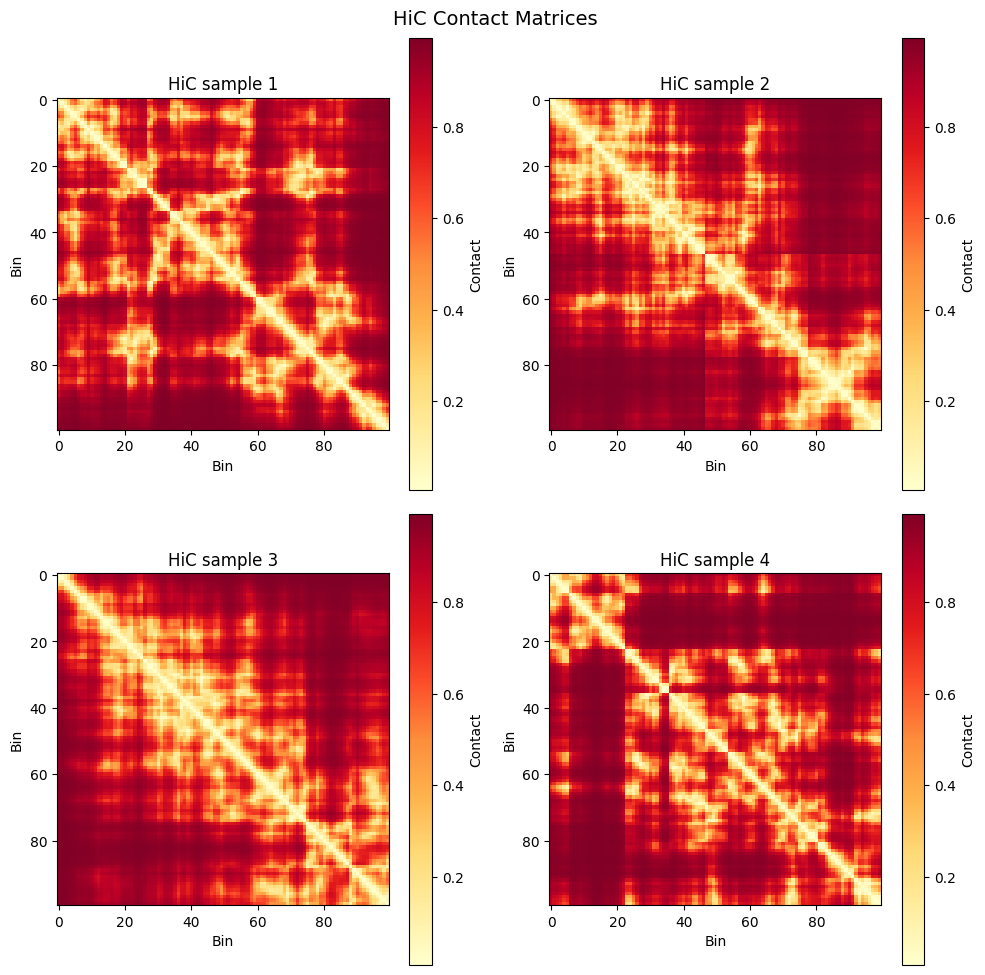

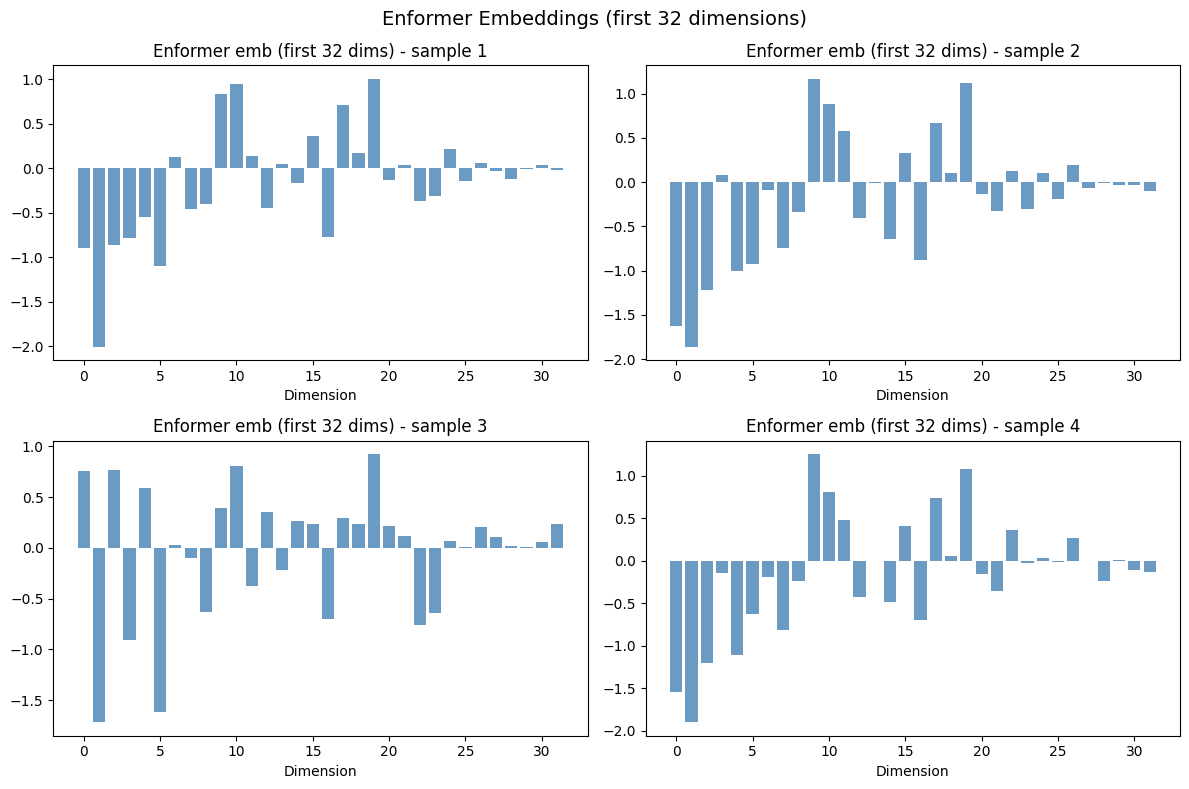

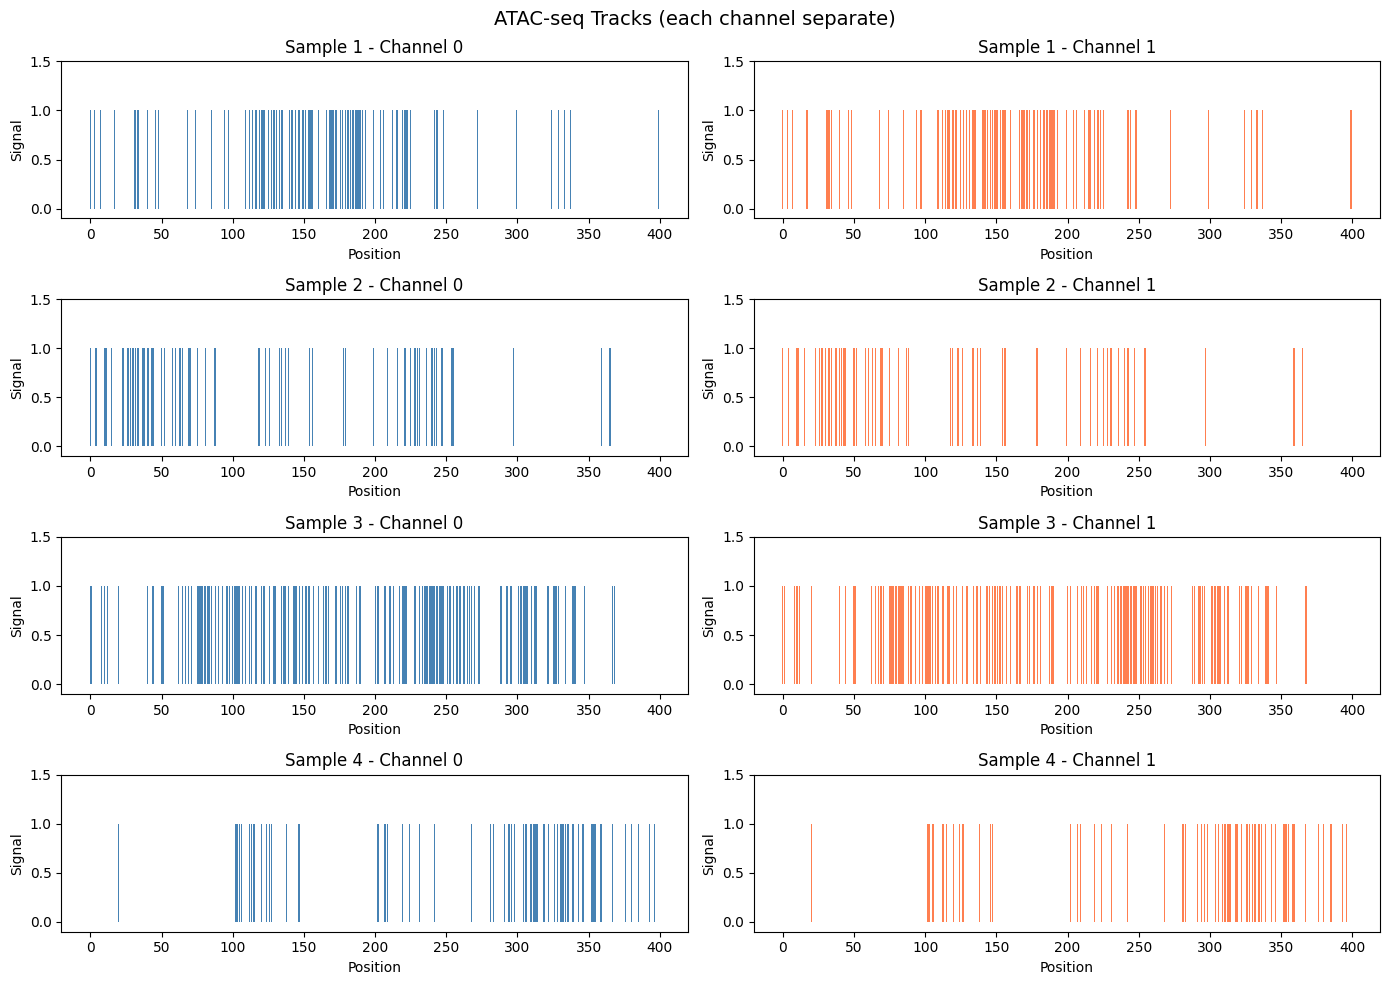

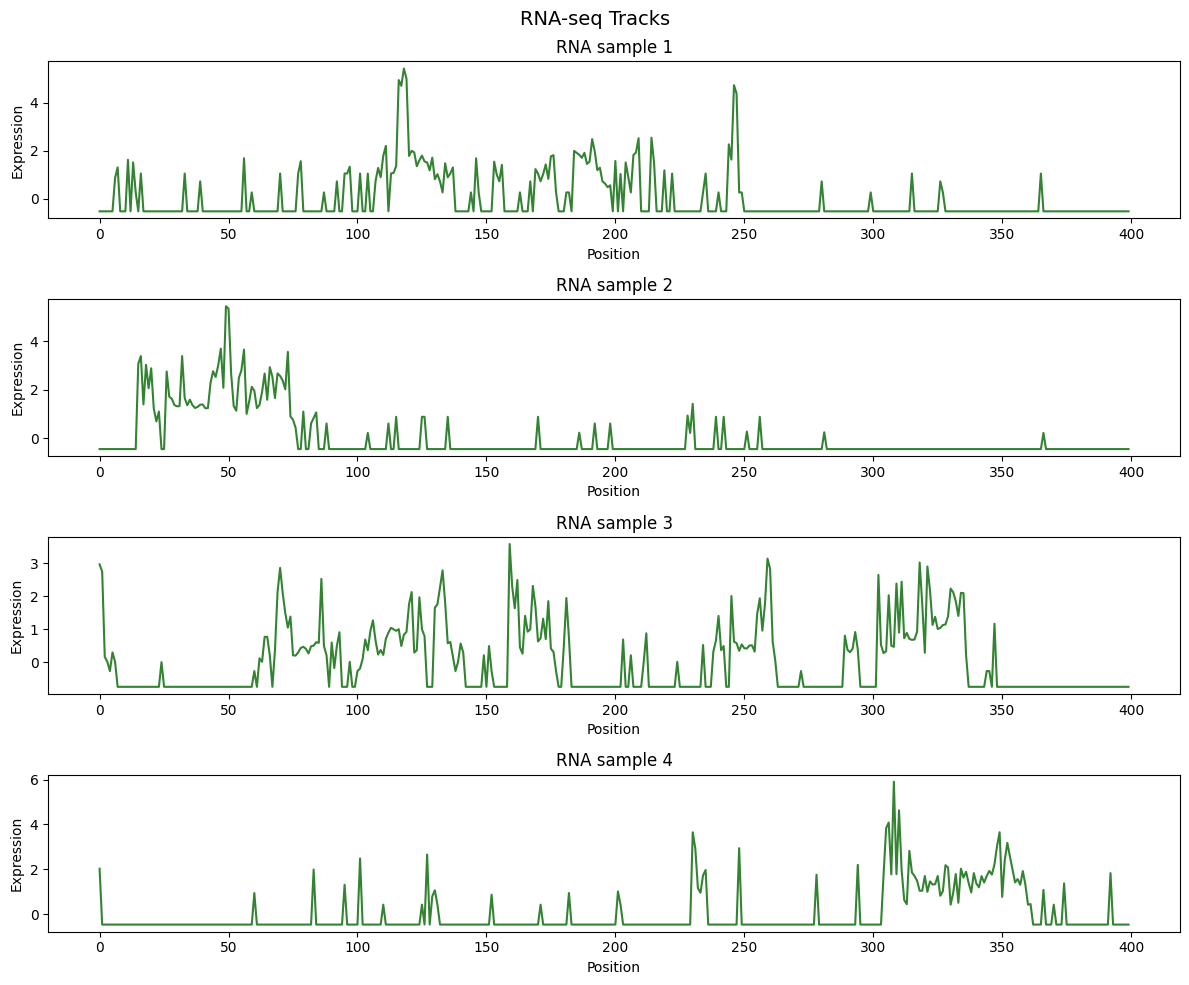

tensor([[[-0.5270],
         [-0.5270],
         [-0.5270],
         ...,
         [-0.5270],
         [-0.5270],
         [-0.5270]],

        [[-0.4487],
         [-0.4487],
         [-0.4487],
         ...,
         [-0.4487],
         [-0.4487],
         [-0.4487]],

        [[ 2.9621],
         [ 2.7422],
         [ 0.1647],
         ...,
         [-0.7405],
         [-0.7405],
         [-0.7405]],

        ...,

        [[-0.6721],
         [-0.6721],
         [-0.6721],
         ...,
         [ 4.9871],
         [ 0.6119],
         [ 0.8643]],

        [[-0.4333],
         [-0.4333],
         [-0.4333],
         ...,
         [ 1.6010],
         [-0.4333],
         [-0.4333]],

        [[-0.1206],
         [ 0.6114],
         [ 0.8061],
         ...,
         [-0.6195],
         [-0.6195],
         [-0.6195]]])


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch for visualization
hic, enf, atac, rna = next(iter(train_loader))

# --- 1. HiC contact matrices (heatmaps) ---
n_hic = min(4, hic.shape[0])  # Show up to 4 samples
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
for i in range(n_hic):
    mat = hic[i, 0].numpy()
    im = axes[i].imshow(mat, cmap='YlOrRd', aspect='equal')
    axes[i].set_title(f'HiC sample {i+1}')
    axes[i].set_xlabel('Bin')
    axes[i].set_ylabel('Bin')
    plt.colorbar(im, ax=axes[i], label='Contact')
for j in range(n_hic, 4):
    axes[j].axis('off')
plt.suptitle('HiC Contact Matrices', fontsize=14)
plt.tight_layout()
plt.show()

# --- 2. Enformer embeddings (first 32 dims as bar plot per sample) ---
n_enf = min(4, enf.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i in range(n_enf):
    emb = enf[i].numpy()[:32]
    axes[i].bar(range(len(emb)), emb, color='steelblue', alpha=0.8)
    axes[i].set_title(f'Enformer emb (first 32 dims) - sample {i+1}')
    axes[i].set_xlabel('Dimension')
for j in range(n_enf, 4):
    axes[j].axis('off')
plt.suptitle('Enformer Embeddings (first 32 dimensions)', fontsize=14)
plt.tight_layout()
plt.show()

# --- 3. ATAC tracks (2 channels) - bar plots, each channel in separate subplot ---
n_atac = min(4, atac.shape[0])
fig, axes = plt.subplots(n_atac, 2, figsize=(14, 2.5 * n_atac))
if n_atac == 1:
    axes = axes.reshape(1, -1)
x = np.arange(400)
for i in range(n_atac):
    atac_i = atac[i].numpy()  # (400, 2)
    axes[i, 0].bar(x, atac_i[:, 0], width=0.8, color='steelblue')
    axes[i, 0].set_title(f'Sample {i+1} - Channel 0')
    axes[i, 0].set_xlabel('Position')
    axes[i, 0].set_ylabel('Signal')
    axes[i, 0].set_ylim(-0.1, 1.5)
    axes[i, 1].bar(x, atac_i[:, 1], width=0.8, color='coral')
    axes[i, 1].set_title(f'Sample {i+1} - Channel 1')
    axes[i, 1].set_xlabel('Position')
    axes[i, 1].set_ylabel('Signal')
    axes[i, 1].set_ylim(-0.1, 1.5)
plt.suptitle('ATAC-seq Tracks (each channel separate)', fontsize=14)
plt.tight_layout()
plt.show()

# --- 4. RNA tracks ---
n_rna = min(4, rna.shape[0])
fig, axes = plt.subplots(n_rna, 1, figsize=(12, 2.5 * n_rna))
if n_rna == 1:
    axes = [axes]
for i in range(n_rna):
    rna_i = rna[i, :, 0].numpy()
    axes[i].plot(rna_i, color='darkgreen', alpha=0.8)
    axes[i].set_title(f'RNA sample {i+1}')
    axes[i].set_xlabel('Position')
    axes[i].set_ylabel('Expression')
plt.suptitle('RNA-seq Tracks', fontsize=14)
plt.tight_layout()
plt.show()

print(rna)